In [1]:
# ==============================
# STEP 1: Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import joblib

In [2]:
# ==============================
# STEP 2: Generate Synthetic Personal Budget Dataset
# ==============================

np.random.seed(42)
random.seed(42)

num_records = 3000

data = []

for i in range(num_records):
    monthly_income = np.random.randint(1000, 6000)

    rent = np.random.randint(int(monthly_income * 0.15), int(monthly_income * 0.45))
    food = np.random.randint(100, 900)
    transport = np.random.randint(50, 500)
    utilities = np.random.randint(80, 600)
    entertainment = np.random.randint(50, 800)
    healthcare = np.random.randint(20, 500)
    education = np.random.randint(0, 700)
    unexpected_expense = np.random.randint(0, 1000)
    savings_target = np.random.randint(100, 1500)

    total_expense = (
        rent + food + transport + utilities +
        entertainment + healthcare + education +
        unexpected_expense
    )

    remaining_balance = monthly_income - total_expense
    expense_income_ratio = total_expense / monthly_income
    savings_gap = remaining_balance - savings_target

    # Rule-based risk labelling for machine learning target
    if remaining_balance < 0 or expense_income_ratio > 1.0:
        budget_risk = "High Risk"
    elif savings_gap < 0 or expense_income_ratio > 0.75:
        budget_risk = "Medium Risk"
    else:
        budget_risk = "Low Risk"

    data.append([
        monthly_income,
        rent,
        food,
        transport,
        utilities,
        entertainment,
        healthcare,
        education,
        unexpected_expense,
        savings_target,
        total_expense,
        remaining_balance,
        expense_income_ratio,
        savings_gap,
        budget_risk
    ])

columns = [
    "monthly_income",
    "rent",
    "food",
    "transport",
    "utilities",
    "entertainment",
    "healthcare",
    "education",
    "unexpected_expense",
    "savings_target",
    "total_expense",
    "remaining_balance",
    "expense_income_ratio",
    "savings_gap",
    "budget_risk"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,monthly_income,rent,food,transport,utilities,entertainment,healthcare,education,unexpected_expense,savings_target,total_expense,remaining_balance,expense_income_ratio,savings_gap,budget_risk
0,1860,549,206,121,100,664,141,466,214,430,2461,-601,1.323118,-1031,High Risk
1,4444,1789,763,180,388,393,433,385,191,1055,4522,-78,1.017552,-1133,High Risk
2,2184,786,413,71,332,797,364,560,474,1182,3797,-1613,1.738553,-2795,High Risk
3,3558,1232,882,239,323,554,150,484,818,746,4682,-1124,1.315908,-1870,High Risk
4,3888,749,373,437,395,63,261,345,564,997,3187,701,0.819702,-296,Medium Risk


In [3]:
# ==============================
# STEP 3: Check Dataset Information
# ==============================

print("Dataset Shape:", df.shape)
print("\nDataset Columns:")
print(df.columns)

print("\nRisk Class Distribution:")
print(df["budget_risk"].value_counts())

df.head(10)

Dataset Shape: (3000, 15)

Dataset Columns:
Index(['monthly_income', 'rent', 'food', 'transport', 'utilities',
       'entertainment', 'healthcare', 'education', 'unexpected_expense',
       'savings_target', 'total_expense', 'remaining_balance',
       'expense_income_ratio', 'savings_gap', 'budget_risk'],
      dtype='object')

Risk Class Distribution:
budget_risk
High Risk      1702
Medium Risk     946
Low Risk        352
Name: count, dtype: int64


,monthly_income,rent,food,transport,utilities,entertainment,healthcare,education,unexpected_expense,savings_target,total_expense,remaining_balance,expense_income_ratio,savings_gap,budget_risk
0,1860,549,206,121,100,664,141,466,214,430,2461,-601,1.323118,-1031,High Risk
1,4444,1789,763,180,388,393,433,385,191,1055,4522,-78,1.017552,-1133,High Risk
2,2184,786,413,71,332,797,364,560,474,1182,3797,-1613,1.738553,-2795,High Risk
3,3558,1232,882,239,323,554,150,484,818,746,4682,-1124,1.315908,-1870,High Risk
4,3888,749,373,437,395,63,261,345,564,997,3187,701,0.819702,-296,Medium Risk
5,2363,445,466,493,534,477,283,34,205,1204,2937,-574,1.242912,-1778,High Risk
6,2955,1004,487,51,469,615,125,476,702,501,3929,-974,1.329611,-1475,High Risk
7,1161,375,369,400,350,505,481,251,701,395,3432,-2271,2.956072,-2666,High Risk
8,1337,566,152,329,296,237,399,492,40,1280,2511,-1174,1.878085,-2454,High Risk
9,3062,1271,164,394,423,178,155,471,62,1262,3118,-56,1.018289,-1318,High Risk


In [4]:
# ==============================
# STEP 4: Save Dataset as CSV
# ==============================

df.to_csv("synthetic_budget_dataset.csv", index=False)

print("Dataset saved successfully as synthetic_budget_dataset.csv")

Dataset saved successfully as synthetic_budget_dataset.csv


In [5]:
# ==============================
# STEP 5: Dataset Summary
# ==============================

df.describe()

,monthly_income,rent,food,transport,utilities,entertainment,healthcare,education,unexpected_expense,savings_target,total_expense,remaining_balance,expense_income_ratio,savings_gap
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,3495.946000,1053.998667,494.869000,273.160000,342.381667,421.700333,254.762667,347.414667,512.958667,805.454000,3701.245667,-205.299667,1.248681,-1010.753667
std,1439.341575,545.914427,232.142765,128.459253,149.010109,216.416883,140.034663,202.279171,290.245450,404.607728,767.250436,1167.056504,0.561688,1235.988410
min,1002.000000,159.000000,100.000000,50.000000,80.000000,51.000000,20.000000,0.000000,0.000000,100.000000,1179.000000,-3236.000000,0.441561,-4251.000000
25%,2244.500000,615.750000,290.750000,163.000000,214.000000,236.000000,131.000000,172.000000,260.000000,457.000000,3150.750000,-1092.250000,0.862748,-1912.000000
50%,3535.500000,962.500000,499.000000,270.000000,346.000000,424.000000,255.000000,342.500000,523.500000,811.500000,3665.000000,-227.500000,1.066827,-1063.000000
75%,4729.250000,1435.250000,691.250000,383.000000,469.250000,613.000000,377.000000,519.000000,766.000000,1166.000000,4231.000000,638.250000,1.490090,-152.000000
max,5994.000000,2676.000000,899.000000,499.000000,599.000000,798.000000,499.000000,699.000000,999.000000,1499.000000,6433.000000,3077.000000,3.630739,2795.000000


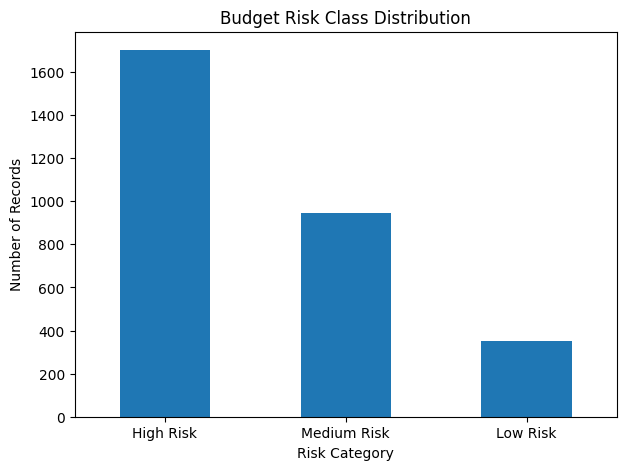

In [6]:
# ==============================
# STEP 6: Risk Class Distribution Chart
# ==============================

risk_counts = df["budget_risk"].value_counts()

plt.figure(figsize=(7, 5))
risk_counts.plot(kind="bar")
plt.title("Budget Risk Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

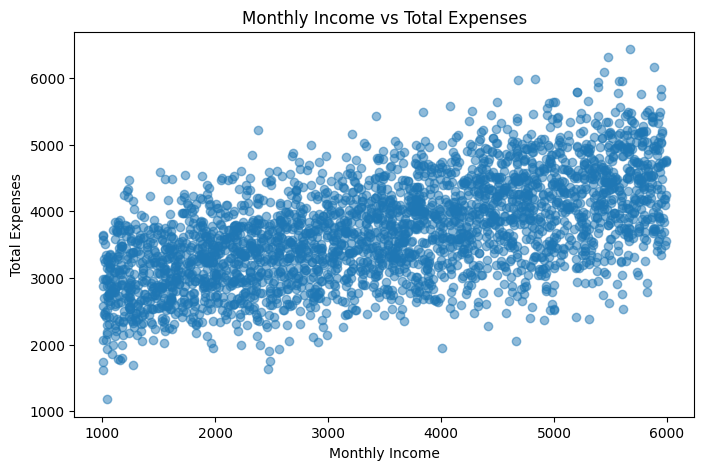

In [7]:
# ==============================
# STEP 7: Income vs Total Expense Scatter Plot
# ==============================

plt.figure(figsize=(8, 5))
plt.scatter(df["monthly_income"], df["total_expense"], alpha=0.5)
plt.title("Monthly Income vs Total Expenses")
plt.xlabel("Monthly Income")
plt.ylabel("Total Expenses")
plt.show()

In [8]:
# ==============================
# STEP 8: Final Dataset Preview
# ==============================

df.head(20)

,monthly_income,rent,food,transport,utilities,entertainment,healthcare,education,unexpected_expense,savings_target,total_expense,remaining_balance,expense_income_ratio,savings_gap,budget_risk
0,1860,549,206,121,100,664,141,466,214,430,2461,-601,1.323118,-1031,High Risk
1,4444,1789,763,180,388,393,433,385,191,1055,4522,-78,1.017552,-1133,High Risk
2,2184,786,413,71,332,797,364,560,474,1182,3797,-1613,1.738553,-2795,High Risk
3,3558,1232,882,239,323,554,150,484,818,746,4682,-1124,1.315908,-1870,High Risk
4,3888,749,373,437,395,63,261,345,564,997,3187,701,0.819702,-296,Medium Risk
5,2363,445,466,493,534,477,283,34,205,1204,2937,-574,1.242912,-1778,High Risk
6,2955,1004,487,51,469,615,125,476,702,501,3929,-974,1.329611,-1475,High Risk
7,1161,375,369,400,350,505,481,251,701,395,3432,-2271,2.956072,-2666,High Risk
8,1337,566,152,329,296,237,399,492,40,1280,2511,-1174,1.878085,-2454,High Risk
9,3062,1271,164,394,423,178,155,471,62,1262,3118,-56,1.018289,-1318,High Risk


# Step 3: Train Machine Learning **Model**

In [9]:
# ==============================
# STEP 9: Prepare Features and Target
# ==============================

feature_columns = [
    "monthly_income",
    "rent",
    "food",
    "transport",
    "utilities",
    "entertainment",
    "healthcare",
    "education",
    "unexpected_expense",
    "savings_target",
    "total_expense",
    "remaining_balance",
    "expense_income_ratio",
    "savings_gap"
]

X = df[feature_columns]
y = df["budget_risk"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

Features shape: (3000, 14)
Target shape: (3000,)

Target classes:
budget_risk
High Risk      1702
Medium Risk     946
Low Risk        352
Name: count, dtype: int64


In [10]:
# ==============================
# STEP 10: Encode Target Labels
# ==============================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded Classes:")
for index, class_name in enumerate(label_encoder.classes_):
    print(index, "=", class_name)

Encoded Classes:
0 = High Risk
1 = Low Risk
2 = Medium Risk


In [11]:
# ==============================
# STEP 11: Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (2400, 14)
Testing Features: (600, 14)
Training Labels: (2400,)
Testing Labels: (600,)


In [12]:
# ==============================
# STEP 12: Feature Scaling
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [13]:
# ==============================
# STEP 13: Train Machine Learning Model
# ==============================

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


In [14]:
# ==============================
# STEP 14: Make Predictions
# ==============================

y_pred = model.predict(X_test_scaled)

print("Prediction completed.")

Prediction completed.


In [15]:
# ==============================
# STEP 15: Model Evaluation
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 99.83 %

Classification Report:
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00       340
    Low Risk       1.00      0.99      0.99        71
 Medium Risk       0.99      1.00      1.00       189

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Confusion Matrix:
[[340   0   0]
 [  0  70   1]
 [  0   0 189]]


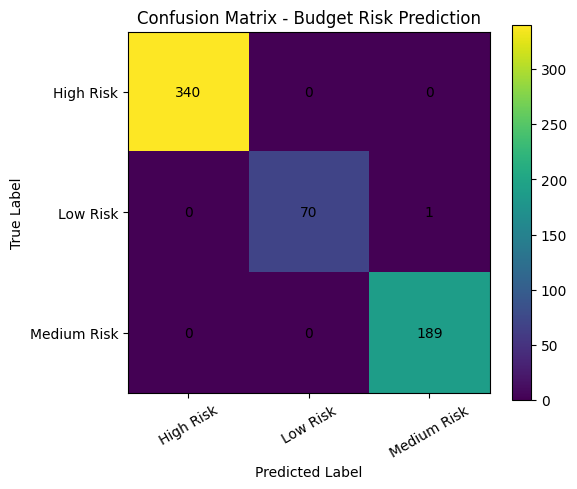

In [16]:
# ==============================
# STEP 16: Confusion Matrix Visualisation
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Budget Risk Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=30
)
plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

                 Feature  Importance
12  expense_income_ratio    0.346369
11     remaining_balance    0.326969
13           savings_gap    0.156798
0         monthly_income    0.081709
10         total_expense    0.038851
1                   rent    0.021908
9         savings_target    0.006399
5          entertainment    0.004278
2                   food    0.004276
8     unexpected_expense    0.003686
6             healthcare    0.003209
4              utilities    0.002161
7              education    0.001699
3              transport    0.001692


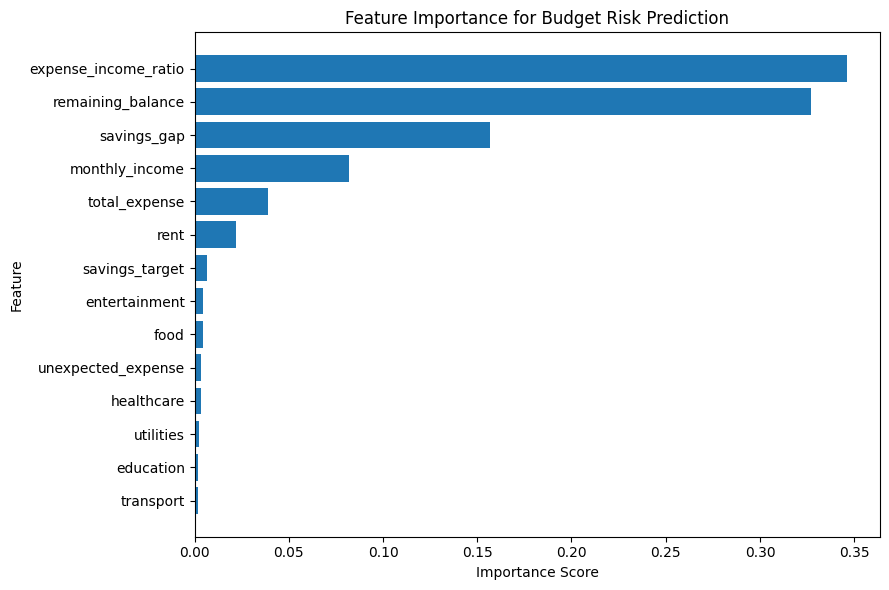

In [17]:
# ==============================
# STEP 17: Feature Importance
# ==============================

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Budget Risk Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# ==============================
# STEP 18: Test Model with a Sample Budget Case
# ==============================

sample_user = pd.DataFrame([{
    "monthly_income": 2500,
    "rent": 900,
    "food": 350,
    "transport": 180,
    "utilities": 220,
    "entertainment": 250,
    "healthcare": 120,
    "education": 100,
    "unexpected_expense": 200,
    "savings_target": 500,
    "total_expense": 2320,
    "remaining_balance": 180,
    "expense_income_ratio": 2320 / 2500,
    "savings_gap": 180 - 500
}])

sample_scaled = scaler.transform(sample_user)
sample_prediction = model.predict(sample_scaled)
sample_prediction_label = label_encoder.inverse_transform(sample_prediction)

print("Predicted Budget Risk:", sample_prediction_label[0])

Predicted Budget Risk: Medium Risk


In [19]:
# ==============================
# STEP 19: Save Model Files
# ==============================

joblib.dump(model, "budget_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model saved as budget_risk_model.pkl")
print("Scaler saved as scaler.pkl")
print("Label encoder saved as label_encoder.pkl")

Model saved as budget_risk_model.pkl
Scaler saved as scaler.pkl
Label encoder saved as label_encoder.pkl


In [20]:
# ==============================
# STEP 20: Save Feature Columns
# ==============================

feature_info = {
    "feature_columns": feature_columns
}

joblib.dump(feature_info, "feature_columns.pkl")

print("Feature columns saved as feature_columns.pkl")

Feature columns saved as feature_columns.pkl


In [21]:
# ==============================
# STEP 21: Download Required Files
# ==============================

from google.colab import files

files.download("budget_risk_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")
files.download("feature_columns.pkl")
files.download("synthetic_budget_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>